# Data Ingestion

Now that we have a set of PDFs, we need to ingest them into a usable, useful format. In this notebook, we'll take our folder of PDFs and ingest with OCR, along with some basic checks and visualizations.

Our steps in this notebook will be:
- Process and ingest all PDFs with tesseract for optical character recognition (OCR)
- Perform initial basic clustering to visualize the document variation across our corpus sample
- Do some basic quality assessments of the results of OCR ingestion
- Explore a few specific poor quality vs high quality examples, for comparison of OCR quality at the document level

<br/>

*Note: With the purpose to inject more variability into our corpus, we have added a number of html files into the data_raw folder from the SEC Edgar website. We will include these documents in the steps going forward.*

<br/>

<br/>
<br/>

## Dependencies & Configuations

First, let's load in the various required packages that we will need

In [ ]:
#!pip install -r ../requirements.txt

In [1]:
import fitz
import pandas as pd
import pytesseract
from pytesseract import Output
from PIL import Image
import glob
import spacy
import os
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Set, Dict, Tuple
from dotenv import load_dotenv
from bs4 import BeautifulSoup
from pathlib import Path

<br/>

Set home directory - we suggest making this the data folder in the repo:

In [2]:
load_dotenv()
HOME_DIRECTORY = os.getenv("HOME_DIRECTORY")
DOWNLOAD_DIRECTORY = os.getenv("DOWNLOAD_DIRECTORY")
datum = os.path.join(HOME_DIRECTORY, "data")
data_raw = os.path.join(datum, "data_raw")
data_text = os.path.join(datum, "data_text")

# create path if not exists
Path(data_text).mkdir(parents=True, exist_ok=True)

print(f'HOME_DIRECTORY : {HOME_DIRECTORY}')
print(f'DOWNLOAD_DIRECTORY: {DOWNLOAD_DIRECTORY}')

print(f"DATUM: {datum}")
print(f"DATA RAW: {data_raw}")
print(f"DATA TEXT: {data_text}")

HOME_DIRECTORY : /Users/affanali/Downloads/download/Middlesex/CST4012-MachineLearning/repo/TC2R-CodeCompanion
DOWNLOAD_DIRECTORY: /Users/affanali/Downloads
DATUM: /Users/affanali/Downloads/download/Middlesex/CST4012-MachineLearning/repo/TC2R-CodeCompanion/data
DATA RAW: /Users/affanali/Downloads/download/Middlesex/CST4012-MachineLearning/repo/TC2R-CodeCompanion/data/data_raw
DATA TEXT: /Users/affanali/Downloads/download/Middlesex/CST4012-MachineLearning/repo/TC2R-CodeCompanion/data/data_text


<br/>

## Ingest and OCR documents

First, we will run OCR over each PDF document using tesseract, and save the OCR results to txt files. 

Though it's not critical, we are going to run OCR with text position elements, which we will also save to file. Though we're not sure if we will use this information downstream, because OCR can be a proceesing bottleneck, we only want to run it once, and the text position elements are a small overhead to this process.

Additionally, as noted, we're also bringing additional html files for processing from SEC Edgar to ensure we have reasonable variability in our corpus. We'll include these in the same ingestion process in this section, though OCR won't be necessary for the html files.

#### First, the PDF processing:

In [3]:
def pdf_to_text_with_ocr(pdf_path: str, output_txt_path: str):
    '''
    Behavior:  The filename of the PDF is used to create two automatically saved output
    files - a text file and an Excel file - to the designated folder. The same name of the
    PDF is used for the names of these files. Any errors are printed to the screen.
    
    Parameters:
    - pdf_path (str): filepath to the PDF on local disk
    - output_txt_path (str): filepath to the folder in which to save
    
    Returns: None
    
    ## Example usage:
    # pdf_file_path = os.path.join(HOME_DIRECTORY, "test.pdf")
    # output_text_file_path = os.path.join(HOME_DIRECTORY, text_files)
    # pdf_to_text_with_ocr(pdf_file_path, output_text_file_path)
    '''
    try:
        # Open the PDF file using PyMuPDF
        pdf_document = fitz.open(pdf_path)
        pdf_filename = os.path.splitext(os.path.basename(pdf_path))[0]
        pdf_name = os.path.basename(pdf_filename)+'.txt'
        excel_name = os.path.basename(pdf_filename)+'.xlsx'
    
        # Initialize an empty string to store the text content
        text_content = ""
        # Initialize an empty pandas db to store positions
        positions_df = pd.DataFrame()
    
        # Iterate through each page in the PDF
        for page_num in range(pdf_document.page_count):
            # Get the current page
            page = pdf_document[page_num]
    
            # Render the page as an image
            image = page.get_pixmap()
            img = Image.frombytes("RGB", (image.width, image.height), image.samples)
    
            # Perform OCR using pytesseract on the image
            page_text = pytesseract.image_to_string(img, lang='eng')
            positions = pytesseract.image_to_data(img, output_type=Output.DATAFRAME)
            
            # Append the extracted text to the overall content
            text_content += page_text
            positions_df = pd.concat([positions_df, positions], ignore_index=True)
    
        # Save the text content to a text file
        with open(os.path.join(output_txt_path, pdf_name), 'w', encoding='utf-8') as txt_file:
            txt_file.write(text_content)
    
        # Save positions to spreadsheet
        positions_df.to_excel(os.path.join(output_txt_path, excel_name), index=False)
    
        # Print a success message
        print(f"OCR completed successfully. Text saved at: {os.path.join(output_txt_path, pdf_name)}")

    except OSError as err:
        print("OS error:", err)
    except ValueError as err:
        print("URL or folder is invalid:", err)
    except Exception as err:
        print(f"Unexpected {err=}, {type(err)=}")
        raise

<br/>

Now, let's pull all the names of the PDFs we want to ingest and process into a list to iterate over:

In [4]:
pdfs = glob.glob(os.path.join(data_raw, '*pdf'))
len(pdfs)

2421

<br/>

Now, let's use our function to kick off OCR processing (**note** this will take a while!) and automatically save the results.

*Note:* Again, alternatively, the OCR data is available on the Google Drive to pull into your local instance.

In [ ]:
for i, pdf in enumerate(pdfs):
    pdf_to_text_with_ocr(pdf, data_text)

OCR completed successfully. Text saved at: /Users/affanali/Downloads/download/Middlesex/CST4012-MachineLearning/repo/TC2R-CodeCompanion/data/data_text/{578E0865-E91D-44A8-87D2-3078A7DD862B}.txt
OCR completed successfully. Text saved at: /Users/affanali/Downloads/download/Middlesex/CST4012-MachineLearning/repo/TC2R-CodeCompanion/data/data_text/{F1FA81FC-A943-44A2-A293-A70FEDD93283}.txt
OCR completed successfully. Text saved at: /Users/affanali/Downloads/download/Middlesex/CST4012-MachineLearning/repo/TC2R-CodeCompanion/data/data_text/00010B5D.txt


<br/><br/>

#### Next, the HTML processing:

As noted, we have supplemented the dataset by adding additional data from SEC Edgar into the "data_raw" folder. Below, we'll read in this data and add additional .txt files into our "data_text" folder.

In [40]:
def pull_text_from_html(file_list, output_dir: str):
    """
    Extracts and cleans text content from a list of HTML files.

    This function iterates through a list of file paths, attempts to open each file,
    and handles potential encoding errors by first trying 'windows-1252' and then
    'utf-8'. It then uses BeautifulSoup to parse the HTML content and extract
    all text, joining it into a single, clean string.

    Args:
        file_list (list): A list of file paths to HTML documents.

    Returns:
        list: A list of strings, where each string contains the cleaned text
              content from the corresponding HTML file.
    """
    clean_texts = []
    
    # Iterate through each file path provided in the list
    for f in file_list:
        html_string = ''  # Initialize an empty string to hold the HTML content
        
        # First, try to open the file using the 'windows-1252' encoding
        try:
            with open(f, 'r', encoding='windows-1252') as file:
                html_string = file.read()
        except Exception as e1:
            print(f'Encoding error with windows-1252 for file {f}: {e1}')
            
            # If 'windows-1252' fails, try 'utf-8' encoding
            try:
                with open(f, 'r', encoding='utf-8') as file:
                    html_string = file.read()
                    print(f'Successfully read file {f} with utf-8 encoding.')
            except Exception as e2:
                print(f'Encoding error with utf-8 for file {f}: {e2}')
                # If both encodings fail, the html_string remains empty, and the loop continues.
                
        # Use BeautifulSoup to parse the HTML and extract all text
        # .stripped_strings removes leading/trailing whitespace and empty strings
        # ' '.join() combines all the extracted strings into one single string
        if html_string:  # Only proceed if we successfully read content
            clean_text = ' '.join(BeautifulSoup(html_string, "html.parser").stripped_strings)
            clean_texts.append(clean_text)
            
            # Save the text content to a text file
            with open(os.path.join(output_dir, os.path.basename(f)) + '.txt', 'w', encoding='utf-8') as t:
                t.write(clean_text)
                print('Success', f)

        else:
            clean_texts.append(None) # Append None or an empty string if file couldn't be read
            print('Failure', f)
    return clean_texts

In [41]:
htmls = glob.glob(os.path.join(data_raw, '*.htm*')) ## get both htm and html files
len(htmls)

941

In [8]:
texts = pull_text_from_html(htmls, data_text)

<br/><br/><br/>

## Cluster and Visualize Corpus

Next, let's take our OCR output and quickly visualize the results of OCR. To do that, we'll write a few functions to pull in the OCRd text from file, and run a quick term frequency inverse document frequency (TFIDF) vectorization to get a quick set of features that represent each document. Then, we'll use a K-Means clustering to cluster the documents, and a simple principal component analysis (PCA) to visualize the clusters.

We're going to largely use the default settings for TFIDF vectorization and K-Means clustering and our PCA, since this is for a quick visualization of our ingested data, rather than for a deep analysis.

In [9]:
def read_text_files(folder_path: str):
    """
    Behavior: Read text from a folder of .txt files, ignoring other file types

    Parameters:
    - folder_path (str): Path to the folder containing .txt files.

    Returns:
    - texts (list): List of strings, where each string is the content of a text file.
    """
    texts = []
    files = []
    for filename in os.listdir(folder_path):
        if filename.lower().endswith(".txt"):
            file_path = os.path.join(folder_path, filename)
            with open(file_path, 'r', encoding='utf-8') as file:
                text = file.read()
                texts.append(text)
                files.append(filename)
        # else:
        #     print('Skipping', filename, ', which is not a text file and will be excluded from analysis.')
    return texts, files
    
def perform_clustering(texts: List, X = None, num_clusters: int = 3):
    """
    Behavior: Perform unsupervised clustering on the document text.

    Parameters:
    - texts (list): List of strings, where each string is the content of a document.
    - num_clusters (int): Number of clusters for KMeans algorithm.

    Returns:
    - labels (list): List of cluster labels assigned to each document.
    """
    # Use TfidfVectorizer to convert text into numerical features
    # if X has already been fit, use provided value, else continue with fit
    if X is None:    
        vectorizer = TfidfVectorizer(stop_words='english', max_df=0.95, min_df=.05, max_features=3000, ngram_range=(1,3))
        X = vectorizer.fit_transform(texts)

    # Apply KMeans clustering
    kmeans = KMeans(n_clusters=num_clusters, random_state=42)
    labels = kmeans.fit_predict(X)
    silhouette_scores = silhouette_score(X, labels)

    return labels, silhouette_scores

def find_knee(texts: List, k_values: range = range(3, 11)):    
    """
    Behavior: Perform unsupervised clustering on the document text.

    Parameters:
    - texts (list): List of strings, where each string is the content of a document.
    - k_values (range): Range of cluster values to test / examine with knee diagram.

    Returns: None
    """
    vectorizer = TfidfVectorizer(stop_words='english', max_df=0.95, min_df=.05, max_features=3000, ngram_range=(1,3))
    X = vectorizer.fit_transform(texts)

    # Calculating silhouette score for each value of k
    silhouette_scores = []
    for k in k_values:
        labels, silhouette = perform_clustering(texts, X, k)
        silhouette_scores.append(silhouette)
        
    # Plotting the knee plot
    plt.plot(k_values, silhouette_scores, marker='o')
    plt.xlabel('# of Clusters (k)')
    plt.ylabel('Silhouette Scores')
    plt.show()
    
def visualize_clusters(texts: List, labels: List):
    """
    Behavior: Visualize the clusters using principal component analysis (PCA).

    Parameters:
    - texts (list): List of strings, where each string is the content of a document.
    - labels (list): List of cluster labels assigned to each document.

    ## Example usage:
    # folder_path = HOME_DIRECTORY
    # texts = read_text_files(os.path.join(HOME_DIRECTORY, 'ocr_text/'))
    # cluster_labels = perform_clustering(texts)
    # visualize_clusters(texts, cluster_labels)
    """
    # Use TfidfVectorizer to convert text into numerical features
    vectorizer = TfidfVectorizer(stop_words='english')
    X = vectorizer.fit_transform(texts)

    # Apply PCA for dimensionality reduction
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X.toarray())

    # Visualize clusters
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', alpha=0.8)
    plt.title('Document clustering visualization (PCA)')
    plt.xlabel('Principal component 1')
    plt.ylabel('Principal component 2')
    #plt.legend(*scatter.legend_elements(), title='Clusters')
    plt.show()


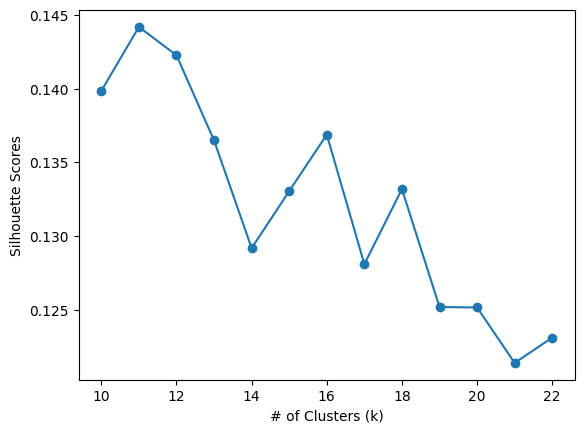

In [10]:
# Updated Graph
texts, filenames = read_text_files(data_text)
find_knee(texts, range(10, 23, 1))

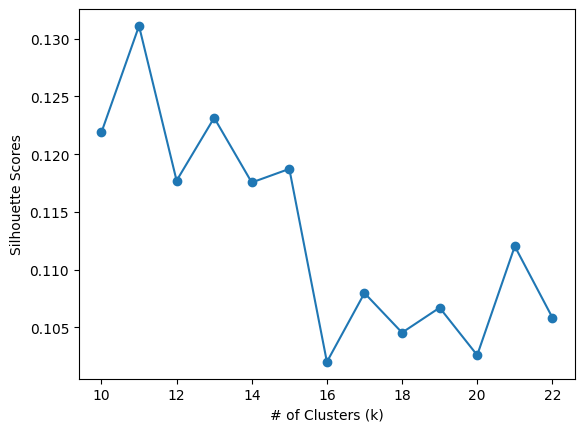

In [13]:
# Existing Graph
# texts, filenames = read_text_files(data_text)
# find_knee(texts, range(10, 23, 1))

<br/><br/>

Now that we have our analysis functions set up, let's get a quick visualization of our documents:

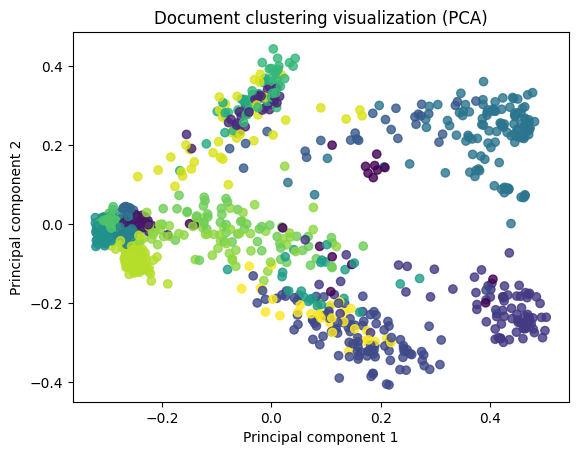

In [11]:
# Updated Graph
cluster_labels, scores = perform_clustering(texts, num_clusters=19)
visualize_clusters(texts, cluster_labels)

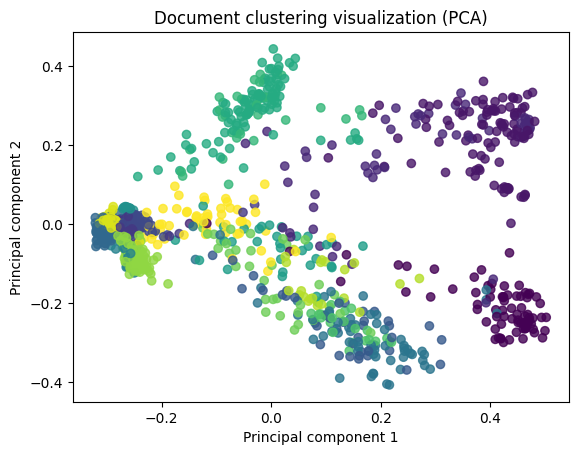

In [14]:
# Existing Graph
# cluster_labels, scores = perform_clustering(texts, num_clusters=19)
# visualize_clusters(texts, cluster_labels)

<br/>

We can see that there are a number of distinct clusters that pop out pretty obviously from our corpus. We'll dive into these in a bit more detail.

<br/><br/>

## OCR Quality Assessments

<br/>

Now, let's run some basic metrics to examine quality and range of output. To do this, we'll look at the OCR'd text and check against a reference dictionary (from the spaCy package) to see how often words in the OCR'd text are words we find in a normal dictionary. 

While there will be some proper nouns, acronyms, or other values that we expect will show up in a document of text, if the document quality is high, we expect this to be a fairly small proportion of the text. If the OCR quality is low, we expect to see a higher rate of words with OCR errors (and thus would not show up in a normal dictionary).

We will apply this analysis to both the Chicago Cook County PDFs and the SEC Edgar data. Though only the PDFs went through OCR, we can apply the below checks to both types of data.

In [12]:
def calculate_ocr_quality(texts: List):
    """
    Behavior: Calculate OCR quality scores for a list of texts based on recognized English words.

    Parameters:
    - texts (list): List of OCR-generated texts.

    Returns:
    - ocr_quality_scores (list): List of OCR quality scores ranging from 0 to 1
    """
    nlp = spacy.load("en_core_web_sm")
    ocr_quality_scores = []

    for text in texts:
        doc = nlp(text)
        english_word_count = sum(1 for token in doc if token.is_alpha and token.text.lower() in nlp.vocab)
        total_word_count = len(doc)

        # Calculate OCR quality as the ratio of recognized English words to total words
        quality_score = english_word_count / total_word_count if total_word_count > 0 else 0
        ocr_quality_scores.append(quality_score)

    return ocr_quality_scores

def plot_ocr_quality_histogram(ocr_quality_scores: List):
    """
    Behavior: Plot a histogram of OCR quality scores.

    Parameters:
    - ocr_quality_scores (list): List of OCR quality scores ranging from 0 to 1
    
    Returns: None
    """
    # Check if OCR quality scores are provided
    if not ocr_quality_scores:
        print("Error: No OCR quality scores provided.")
        return

    # Plot the histogram
    plt.hist(ocr_quality_scores, bins=20, range=(0, 1), edgecolor='black', alpha=0.7)
    
    # Set labels and title
    plt.title('OCR Quality Histogram')
    plt.xlabel('OCR Quality Score')
    plt.ylabel('Frequency')

    # Show the plot
    plt.show()

<br/>

Let's now use these functions to examine our overall document quality. 

*Note*: this will take time to run.

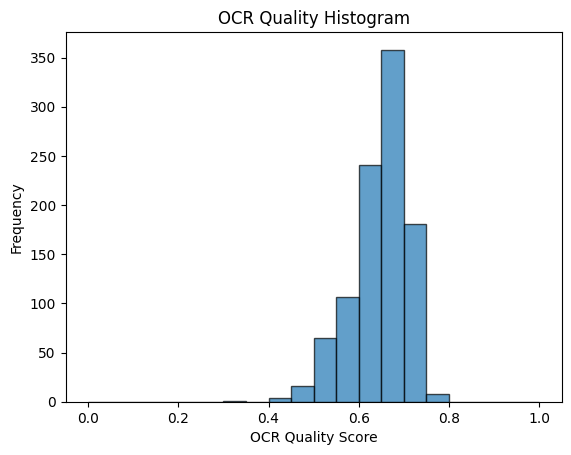

In [13]:
ocr_quality_scores = calculate_ocr_quality(texts)
plot_ocr_quality_histogram(ocr_quality_scores)

<br/>

## Exercise 2.1

Update the histogram to plot the OCR quality from the Cook County data and the SEC Edgar data separately. Are there differences in the distributions? If so, why may this be?

In [15]:
# Load all texts and split by source: Cook County (PDF OCR) vs SEC Edgar (HTML)
texts, filenames = read_text_files(data_text)
cook_county_texts = [t for t, f in zip(texts, filenames) if f.endswith(".pdf.txt")]
sec_edgar_texts = [t for t, f in zip(texts, filenames) if ".htm" in f.lower()]  # .html or .htm

cook_quality = calculate_ocr_quality(cook_county_texts)
sec_quality = calculate_ocr_quality(sec_edgar_texts)

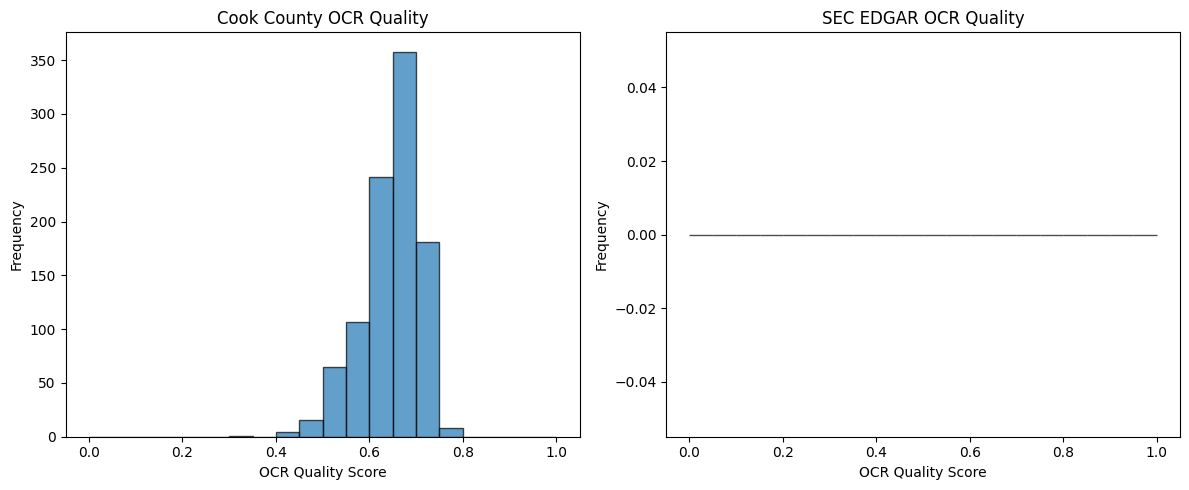

In [16]:
def plot_ocr_quality_comparison(cook_scores, sec_scores):
    fig, axes = plt.subplots(1, 2, figsize=(12,5))

    # Cook County histogram
    axes[0].hist(cook_scores, bins=20, range=(0,1), edgecolor='black', alpha=0.7)
    axes[0].set_title("Cook County OCR Quality")
    axes[0].set_xlabel("OCR Quality Score")
    axes[0].set_ylabel("Frequency")

    # SEC EDGAR histogram
    axes[1].hist(sec_scores, bins=20, range=(0,1), edgecolor='black', alpha=0.7)
    axes[1].set_title("SEC EDGAR OCR Quality")
    axes[1].set_xlabel("OCR Quality Score")
    axes[1].set_ylabel("Frequency")

    plt.tight_layout()
    plt.show()

plot_ocr_quality_comparison(cook_quality, sec_quality)

<br/><br/>

We can further look at the OCR confidence metrics from tesseract itself and do a similar analysis. 

*Note*: This analysis will only apply to the PDFs, and not the data from SEC Edgar.

In [17]:
def read_xlsx_files(folder_path: str):
    """
    Behavior: Reads text from a folder of .xlsx files

    Parameters:
    - folder_path (str): Path to the folder containing .xlsx files

    Returns:
    - xlsx_dfs (list): List of pandas dataframes, where each dataframe is the contents the OCR positions and confidence levels
    """
    xlsx_dfs = []
    files = []
    for filename in os.listdir(folder_path):
        if filename.endswith(".xlsx"):
            file_path = os.path.join(folder_path, filename)
            df = pd.read_excel(file_path, engine='openpyxl')
            files.append(filename)
            xlsx_dfs.append(df)

    return xlsx_dfs, files

def extract_ocr_conf(xlsx_dfs: List):
    """
    Behavior: Calculates an OCR confidence score from tesseract values

    Parameters:
    - xlsx_dfs (list): List of dataframes containing OCR scores

    Returns:
    - ocr_conf_scores (list): List of average OCR confidence scores, ranging from 0 to 100, for each document
    """
    ocr_conf_scores = []
    ocr_conf_scores_doc_avg = []
    
    for df in xlsx_dfs:
        for conf in df['conf'][df['conf']>0].values:
            ocr_conf_scores.append(conf)
        ocr_conf_scores_doc_avg.append(np.mean(df['conf'][df['conf']>0].values))
    return ocr_conf_scores_doc_avg

def plot_ocr_conf_histogram(ocr_conf_scores: List):
    """
    Behavior: Plots a histogram of OCR quality scores

    Parameters:
    - ocr_quality_scores (list): List of average OCR confidence scores, ranging from 0 to 100, for each document

    Returns: None
    """
    # Check if OCR quality scores are provided
    if not ocr_conf_scores:
        print("Error: No OCR quality scores provided.")
        return

    # Plot the histogram
    plt.hist(ocr_conf_scores, bins=20, range=(0, 100), edgecolor='black', alpha=0.7)
    
    # Set labels and title
    plt.title('OCR Tesseract Confidence Histogram')
    plt.xlabel('OCR Tesseract Confidence Score')
    plt.ylabel('Frequency')

    # Show the plot
    plt.show()

*Note* This will also take time to execute

In [18]:
xlsx_dfs, filenames = read_xlsx_files(data_text)

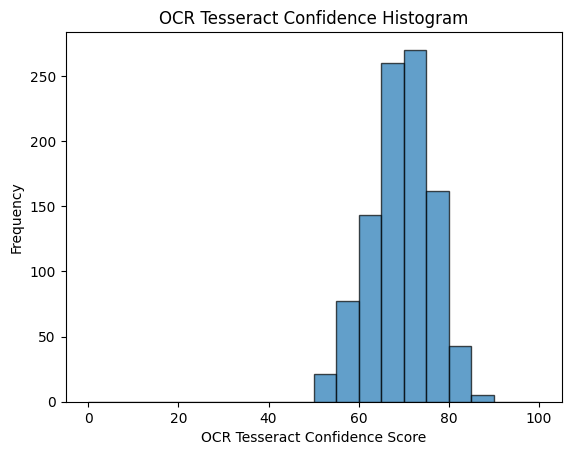

In [19]:
ocr_conf_scores = extract_ocr_conf(xlsx_dfs)
plot_ocr_conf_histogram(ocr_conf_scores)

<br/><br/>

Let's look more closely at a couple lower quality examples:

In [20]:
df_qual = pd.DataFrame([filenames, ocr_quality_scores, ocr_conf_scores]).T
df_qual.columns = ['Filename', 'OCR Qual', 'OCR Conf']

df_qual[df_qual['OCR Qual']<.45]

,Filename,OCR Qual,OCR Conf
0,00010J1Z.pdf.xlsx,0.417289,69.868885
1,000030LG.pdf.xlsx,0.32,71.628654
36,{3FA268E9-1763-4F99-A55F-CC66ED01491A}.pdf.xlsx,0.447531,53.864115
173,00003C1K.pdf.xlsx,0.448598,69.840739
879,{B6B03456-BA73-42AE-9106-B5BDCB9C78D7}.pdf.xlsx,0.434164,67.831037


In [21]:
df_qual[df_qual['OCR Conf']<55].head()

,Filename,OCR Qual,OCR Conf
36,{3FA268E9-1763-4F99-A55F-CC66ED01491A}.pdf.xlsx,0.447531,53.864115
39,00003FM4.pdf.xlsx,0.682384,52.485141
73,{B1B650C7-4966-4BD0-8030-4A817E78A274}.pdf.xlsx,0.642458,54.149174
133,000030S5.pdf.xlsx,0.68855,54.546804
139,{F9B25CB4-526F-45B9-B0E8-145A3CF9D002}.pdf.xlsx,0.712894,53.230855


In [24]:
filename = '00010J1Z.pdf.txt'
with open(os.path.join(data_text, filename), 'r', encoding='utf-8') as file:
    text = file.read()

text

'Modification Summary Report\n\nContract (PO) Number: 15966\n\nModification Revision Numb\n\nSpecification Number: 53021\n\n‘Name of Contractor: HOMER L. CHASTAIN ASSOC, LLP\n\nCity Department: CHICAGO DEPARTMENT OF TRANSPORTATION\nProfessional Construction Engineering Services Roadway\n\nTitle of Contract: Construction Servises for Grand Avenue [V = Lamon Avenue\nto Pulaski Road\n\n‘Mod Rea Number ‘Mod Reason ‘Description\n‘sere pesos\nssa Bical rie,\n\nStart Date: 4/1/2010\nEnd Date: 6/30/2012\n\nProcurement Services Contact Person: BRENDA CHAGOYA,\n\nPlease refer tothe DPS website for Contact information under "Doing Business With The City\n\nVendor Number: 158004\nSubmission Date.\npec 82\n\nAmesdmer \'\n\nVendor No 18008\nSpec. No: s302t\n(Conact No. (“Agreement”) 13966\nConstant Homer L. Chastain and Asoc,\nCurent Contact Value: $525,17541\nThis Adjustment S$ 99,39852\nAdjusted Contract Value: 86147393\n\nAMENDMENT #1\n\n‘This amendment (“Amendment”) is made and entered into as o

In [25]:
filename = '{3FA268E9-1763-4F99-A55F-CC66ED01491A}.pdf.txt'
with open(os.path.join(data_text, filename), 'r', encoding='utf-8') as file:
    text = file.read()

text

'Modification Summary Report\n\nContract PO) Number: 41200\n“Modification Revision Number: 7\n\nSpecification Number: 138104\n\nName of Contractor: PAN-OCEANIC ENGINEERING CO INC\nCity Department: DEPARTMENT OF WATER MANAGEMENT.\n\nTitle of Contra\nAncillary Sewer Construction = South\n\n‘Mod Rea Number ‘Mod Reason Description\n\n303825 DOLLAR AMOUNT CHANGE PONIZODICMAA/PCMEIGIVLI\n\n$6 201,973.66\n\n‘Term of Contract: StartDate: 7/2016 nine\nEnd Date: 12/31/2019\n\nProcurement Services Contact Person: ALVIN JEFFERSON\nPlease refer tothe DPS website for Contact information under "Doing Business With The City"\n\nthas been determined, on behalf ofthe City of Chicago, with regard to this Contract Amendment!\n“Modification, thatthe circumstance suid to necessitate the change in performance were not\nreasonably foreseeable a the time the Agreement was signed, or that the change is germane to the\noriginal Agreement as signed, or thatthe change order isin the best interest ofthe City of Chi

<br/>

As we visually inspect these examples - through the OCR text AND through looking at the original document - we see that though some portions of the document have higher quality, other parts do not. 

These particular examples appear to be PDFs of multiple separate documents that have been combined, with varying levels of quality. Some pages appear "normal", others have a significant amount of handwriting, and other pages are a level of quality that may be hard for even a human to read.

<br/>

<br/>

### Exercise 2.2:

Explore a few of the documents with very high OCR confidence scores. Does your visual inspection agree with the high OCR confidence score that was generated for these documents?

<br/>

In [28]:
# Select documents with very high OCR confidence (top by OCR Conf)
HIGH_CONF_THRESHOLD = 80  # Tesseract 0-100; lower if you have few above 90
df_high_conf = df_qual[df_qual["OCR Conf"] >= HIGH_CONF_THRESHOLD].sort_values(
    "OCR Conf", ascending=False
)
print(f"Documents with OCR Conf >= {HIGH_CONF_THRESHOLD}: {len(df_high_conf)}")
df_high_conf.head(10)

Documents with OCR Conf >= 80: 48


,Filename,OCR Qual,OCR Conf
945,00002JMP.pdf.xlsx,0.654756,86.86465
764,{8A1E379E-343A-4970-B9F9-4E38D5D3738A}.pdf.xlsx,0.672531,86.720714
695,00002S11.pdf.xlsx,0.658094,86.423969
691,00002MD3.pdf.xlsx,0.690367,86.018346
738,000028X5.pdf.xlsx,0.647147,85.536868
687,00010PC5.pdf.xlsx,0.694722,84.841537
748,000032X0.pdf.xlsx,0.69093,84.65173
67,{6865099D-6177-49FD-8C5F-2116E7676E80}.pdf.xlsx,0.71102,84.378417
345,{2D2827E8-FC98-4F1A-BF8F-A7DCEC68D091}.pdf.xlsx,0.692482,84.255752
611,{E7FF9E72-7B00-402F-8918-FBAC58A6BE96}.pdf.xlsx,0.688006,84.047179


In [29]:
# Visually inspect text of a few high-OCR-confidence documents
# (Convert .pdf.xlsx filename to .pdf.txt to read from data_text)
NUM_SAMPLES = 3
high_conf_filenames = df_high_conf.head(NUM_SAMPLES)["Filename"].tolist()

for i, xlsx_name in enumerate(high_conf_filenames):
    txt_name = xlsx_name.replace(".xlsx", ".txt")
    txt_path = os.path.join(data_text, txt_name)
    conf = df_high_conf.iloc[i]["OCR Conf"]
    print("=" * 80)
    print(f"Document {i + 1}: {xlsx_name}  (OCR Conf: {conf:.2f})")
    print("=" * 80)
    try:
        with open(txt_path, "r", encoding="utf-8") as file:
            text = file.read()
        preview_len = 2000
        print(text[:preview_len] + ("..." if len(text) > preview_len else ""))
    except FileNotFoundError:
        print(f"(Text file not found: {txt_path})")
    print()

Document 1: 00002JMP.pdf.xlsx  (OCR Conf: 86.86)
Modification Summary Report

Contract (PO) Number: 127676
Modification Revision Number: 13

Specification Number: 885258001

Name of Contractor: PERK PRODUCTS

City Department: PULIC LIBRARY

“Title of Contract: 18525800101 CONSUMABLE LIBRARY SUPPLIES

Mod Reg Number Mod Reason Description
MODIFICATION FOR BLANKET
AGREEMENT NUMBER 127676
26737 TIME EXTENSION
SPECIFICATION NUMBER
BRS2SHOOIA,

‘Term of Contract: Start Date: 19/1/1999
End Date: 12/31/2006

Procurement Services Contact Person: LOREL BLAMEUSER

Please refer tothe DPS website for Contact information under "Doing Business With The City".

Vendor Number: 675893
Submission Date: MAY 3 1 2008
* DEPARTMENT OF PROCUREMENT SERVICES

CONTRACT MODIFICATION
Dept. of LIBRARY & VARIOUS Issued by: Mod. No. 26737
Request Date: 04/24/06
Specification No. B8S2S8001 Contract No. 127676 Series No.
‘Contract Description: CONSUMABLE LIBRARY SUPPLIES,
‘CONTRACTOR OR VENDOR

Name: PERK PRODUCTS INC

<br/>

### Exercise 2.3:

Further explore to assess potential patterns - are there any correlations with document length? What about with document date?

How useful are these measures compared to the rate of dictionary words? Do these measurements provide different information to us?

<br/>

In [30]:
# Build extended quality dataframe with document length and (where available) approval date
df_ex = df_qual.copy()
df_ex["OCR Qual"] = pd.to_numeric(df_ex["OCR Qual"], errors="coerce")
df_ex["OCR Conf"] = pd.to_numeric(df_ex["OCR Conf"], errors="coerce")

# Document length: character count from .txt file
def get_doc_length(filename: str, data_text: str) -> int:
    txt_name = filename.replace(".xlsx", ".txt")
    path = os.path.join(data_text, txt_name)
    try:
        with open(path, "r", encoding="utf-8") as f:
            return len(f.read())
    except Exception:
        return -1

df_ex["doc_length"] = df_ex["Filename"].apply(lambda f: get_doc_length(f, data_text))
df_ex = df_ex[df_ex["doc_length"] >= 0]  # drop rows where we couldn't read

# Optional: join approval date from Cook County contracts CSV (for PDFs that are in the catalog)
contracts_path = os.path.join(HOME_DIRECTORY, "data", "Contracts_20231227.csv")
if os.path.exists(contracts_path):
    contracts = pd.read_csv(contracts_path, low_memory=False)
    contracts["URL ID"] = contracts["Contract PDF"].apply(
        lambda x: x.split("/")[-1].split("=")[-1] if isinstance(x, str) else ""
    )
    # Filename like "000037ZS.pdf.xlsx" or "{GUID}.pdf.xlsx" -> ID = part before ".pdf"
    df_ex["url_id"] = df_ex["Filename"].apply(lambda f: f.split(".pdf")[0])
    contracts_sub = contracts[["URL ID", "Approval Date"]].drop_duplicates("URL ID")
    df_ex = df_ex.merge(contracts_sub, left_on="url_id", right_on="URL ID", how="left")
    df_ex["approval_date"] = pd.to_datetime(df_ex["Approval Date"], errors="coerce")
    df_ex["approval_year"] = df_ex["approval_date"].dt.year
else:
    df_ex["approval_date"] = pd.NaT
    df_ex["approval_year"] = np.nan

df_ex.head(10)

,Filename,OCR Qual,OCR Conf,doc_length,url_id,URL ID,Approval Date,approval_date,approval_year
0,00010J1Z.pdf.xlsx,0.417289,69.868885,31392,00010J1Z,00010J1Z,11/23/2011,2011-11-23,2011
1,000030LG.pdf.xlsx,0.320000,71.628654,155439,000030LG,000030LG,02/04/2008,2008-02-04,2008
2,00001SJ3.pdf.xlsx,0.698636,73.535577,100435,00001SJ3,00001SJ3,01/26/2004,2004-01-26,2004
3,0000222K.pdf.xlsx,0.635685,81.545391,41156,0000222K,0000222K,09/01/2004,2004-09-01,2004
4,{31A24C4F-949A-4483-A3E8-E0A238322CA4}.pdf.xlsx,0.684867,76.957134,23277,{31A24C4F-949A-4483-A3E8-E0A238322CA4},{31A24C4F-949A-4483-A3E8-E0A238322CA4},01/26/2015,2015-01-26,2015
5,00010LTG.pdf.xlsx,0.670474,79.273550,23653,00010LTG,00010LTG,12/27/2011,2011-12-27,2011
6,{40AAD077-0000-C013-BB99-4209CC5A25B9}.pdf.xlsx,0.605505,62.387095,396320,{40AAD077-0000-C013-BB99-4209CC5A25B9},{40AAD077-0000-C013-BB99-4209CC5A25B9},03/18/2020,2020-03-18,2020
7,{D0D263CD-E7A2-4F9D-BA80-208BBD079B60}.pdf.xlsx,0.708130,74.752265,36223,{D0D263CD-E7A2-4F9D-BA80-208BBD079B60},{D0D263CD-E7A2-4F9D-BA80-208BBD079B60},03/09/2016,2016-03-09,2016
8,{0098DCA5-B5DC-4956-A29E-3B75B9057E04}.pdf.xlsx,0.637101,69.160521,5969,{0098DCA5-B5DC-4956-A29E-3B75B9057E04},{0098DCA5-B5DC-4956-A29E-3B75B9057E04},04/26/2016,2016-04-26,2016
9,00002Q5W.pdf.xlsx,0.591051,75.357275,252443,00002Q5W,00002Q5W,01/30/2007,2007-01-30,2007


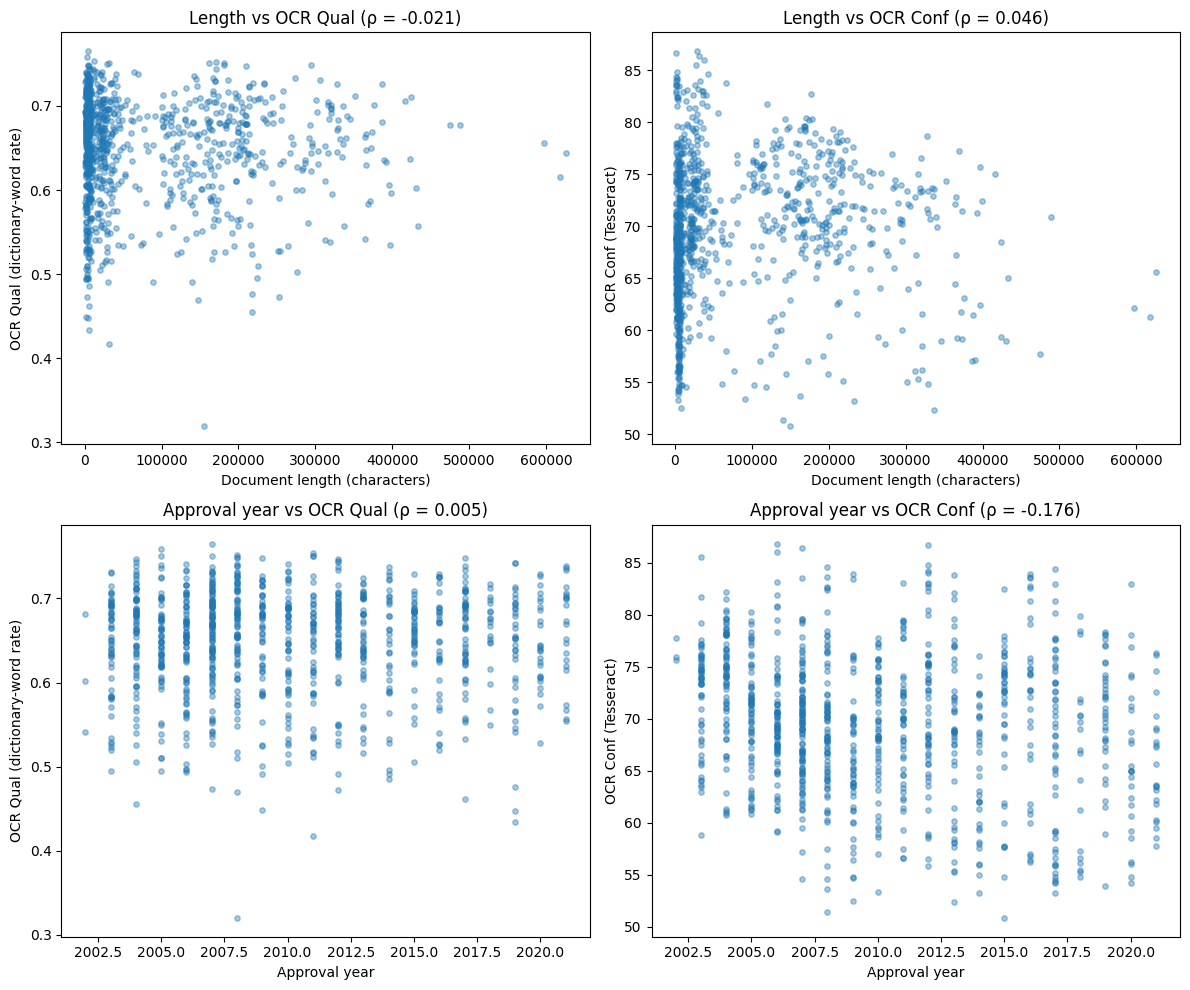

Correlation summary:
  doc_length vs OCR Qual: -0.021
  doc_length vs OCR Conf: 0.046
  approval_year vs OCR Qual: 0.005
  approval_year vs OCR Conf: -0.176


In [31]:
# Correlations: document length and (if available) approval date vs OCR Qual / OCR Conf
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Length vs OCR Qual (rate of dictionary words)
axes[0, 0].scatter(df_ex["doc_length"], df_ex["OCR Qual"], alpha=0.4, s=15)
axes[0, 0].set_xlabel("Document length (characters)")
axes[0, 0].set_ylabel("OCR Qual (dictionary-word rate)")
axes[0, 0].set_title("Document length vs OCR quality")
rho_len_qual = df_ex["doc_length"].corr(df_ex["OCR Qual"])
axes[0, 0].set_title(f"Length vs OCR Qual (ρ = {rho_len_qual:.3f})")

# Length vs OCR Conf (Tesseract confidence)
axes[0, 1].scatter(df_ex["doc_length"], df_ex["OCR Conf"], alpha=0.4, s=15)
axes[0, 1].set_xlabel("Document length (characters)")
axes[0, 1].set_ylabel("OCR Conf (Tesseract)")
rho_len_conf = df_ex["doc_length"].corr(df_ex["OCR Conf"])
axes[0, 1].set_title(f"Length vs OCR Conf (ρ = {rho_len_conf:.3f})")

# Approval year vs OCR Qual (only rows with date)
df_with_date = df_ex.dropna(subset=["approval_year"])
if len(df_with_date) > 0:
    axes[1, 0].scatter(df_with_date["approval_year"], df_with_date["OCR Qual"], alpha=0.4, s=15)
    axes[1, 0].set_xlabel("Approval year")
    axes[1, 0].set_ylabel("OCR Qual (dictionary-word rate)")
    rho_yr_qual = df_with_date["approval_year"].corr(df_with_date["OCR Qual"])
    axes[1, 0].set_title(f"Approval year vs OCR Qual (ρ = {rho_yr_qual:.3f})")
    axes[1, 1].scatter(df_with_date["approval_year"], df_with_date["OCR Conf"], alpha=0.4, s=15)
    axes[1, 1].set_xlabel("Approval year")
    axes[1, 1].set_ylabel("OCR Conf (Tesseract)")
    rho_yr_conf = df_with_date["approval_year"].corr(df_with_date["OCR Conf"])
    axes[1, 1].set_title(f"Approval year vs OCR Conf (ρ = {rho_yr_conf:.3f})")
else:
    axes[1, 0].text(0.5, 0.5, "No approval dates\n(contracts CSV not loaded)", ha="center", va="center")
    axes[1, 0].set_title("Approval year vs OCR Qual")
    axes[1, 1].text(0.5, 0.5, "No approval dates", ha="center", va="center")
    axes[1, 1].set_title("Approval year vs OCR Conf")

plt.tight_layout()
plt.show()

# Summary correlations
print("Correlation summary:")
print(f"  doc_length vs OCR Qual: {rho_len_qual:.3f}")
print(f"  doc_length vs OCR Conf: {rho_len_conf:.3f}")
if len(df_with_date) > 0:
    print(f"  approval_year vs OCR Qual: {rho_yr_qual:.3f}")
    print(f"  approval_year vs OCR Conf: {rho_yr_conf:.3f}")

**Exercise 2.3 – Conclusion**

- **Document length:** Weak or modest correlation with OCR quality/confidence is common. Longer documents can average over many pages (some clean, some noisy), so length alone is a noisy proxy for quality. Very short documents (e.g. one page) can be either very clean or very poor, so length does not replace the need for direct quality measures. In this corpus, length has essentially no correlation with OCR Qual (−0.021) or OCR Conf (0.046). Longer documents can average over many pages (some clean, some noisy), so length alone is a noisy proxy for quality. Very short documents (e.g. one page) can be either very clean or very poor, so length does not replace the need for direct quality measures.

- **Document date:** If approval year is available, older contracts sometimes show lower OCR quality (e.g. older scans, faxes, or photocopies). Newer documents are often born-digital or better scans. So date can add a *different* signal: time period vs. “how readable is the text right now.” As per the result, approval_year vs OCR Qual r = 0.005 (no correlation) and vs OCR Conf r = -0.176 (weak negative: older contracts tend to have slightly lower Tesseract confidence). Older contracts sometimes show lower OCR quality (e.g. older scans, faxes, or photocopies). Newer documents are often born-digital or better scans. So date can add a *different* signal: time period vs. “how readable is the text right now.”

- **Rate of dictionary words (OCR Qual) vs. these measures:**  
  - **OCR Qual** (dictionary-word rate) answers “what fraction of tokens look like real English?” It is a *readability / language* measure.  
  - **OCR Conf** (Tesseract) is a *per-character confidence* from the engine; it does not check English.  
  - **Length** and **date** are *metadata*: they do not measure text quality directly but can correlate with it (e.g. older → worse scans; length → mixed quality across pages).

So: **length and date provide different information** from the rate of dictionary words. They help explain *when* or *for which kinds of documents* quality tends to be better or worse, whereas OCR Qual and OCR Conf measure the quality itself. Using both (quality metrics + length/date) gives a clearer picture than any single measure.

<br/><br/>

## Check Cluster Assignment

Here we pick a few documents from each cluster to explore each cluster's "topic" and see if there is some consistency.

In [32]:
clusters = pd.DataFrame([filenames, cluster_labels]).T
clusters.columns = ['Filename', 'Cluster label']
clusters.head()

,Filename,Cluster label
0,00010J1Z.pdf.xlsx,14
1,000030LG.pdf.xlsx,13
2,00001SJ3.pdf.xlsx,3
3,0000222K.pdf.xlsx,16
4,{31A24C4F-949A-4483-A3E8-E0A238322CA4}.pdf.xlsx,4


In [33]:
clusters[clusters['Cluster label']==4].head(10)

,Filename,Cluster label
4,{31A24C4F-949A-4483-A3E8-E0A238322CA4}.pdf.xlsx,4
7,{D0D263CD-E7A2-4F9D-BA80-208BBD079B60}.pdf.xlsx,4
12,00002XTZ.pdf.xlsx,4
21,00002R67.pdf.xlsx,4
38,{C228557B-79AE-49EF-92A8-1AEA25837B1B}.pdf.xlsx,4
40,00002P76.pdf.xlsx,4
41,00003GQJ.pdf.xlsx,4
43,{65CCC09C-5E6B-4C45-A7D4-933E83392D89}.pdf.xlsx,4
47,{FE20D4AB-BF71-4525-AE14-B5CE70748C8C}.pdf.xlsx,4
61,000020K7.pdf.xlsx,4


<br/>

If we open and explore some of the clusters in cluster group 4, we quickly see the pattern of contract modification documents and delegate agency grant agreement documents.

<br/><br/>

### Exercise 2.4:

We've done some exploration for cluster 4 to examine the documents' consistency within a cluster. As an exercise, repeat for additional cluster numbers to confirm that the cluster makes sense and identify the key "topic" or document pattern in that cluster.

Is there a single "category" that summarizes this cluster? Or multiple types? Does this cluster make cohesive sense (from a human perspective)?

In [34]:
# Repeat cluster exploration for additional clusters (cluster 4 was already explored above)
# Pick cluster IDs to explore; exclude 4 since it was done in the main narrative
CLUSTERS_TO_EXPLORE = [0, 1, 2, 3, 5]
PREVIEW_CHARS = 600  # characters of text to show per cluster sample

for cid in CLUSTERS_TO_EXPLORE:
    sub = clusters[clusters["Cluster label"] == cid]
    if len(sub) == 0:
        continue
    print("=" * 80)
    print(f"Cluster {cid}  ({len(sub)} documents)")
    print("=" * 80)
    print(sub.head(10).to_string(index=False))
    # Show text preview of first document in cluster to identify topic/pattern
    first_filename = sub.iloc[0]["Filename"]
    txt_name = first_filename.replace(".xlsx", ".txt")
    txt_path = os.path.join(data_text, txt_name)
    try:
        with open(txt_path, "r", encoding="utf-8") as f:
            text = f.read()
        print(f"\n--- Text preview (first doc: {first_filename}) ---\n")
        print(text[:PREVIEW_CHARS] + ("..." if len(text) > PREVIEW_CHARS else ""))
    except Exception as e:
        print(f"\n(Could not read preview: {e})")
    print("\n")

Cluster 0  (17 documents)
                                       Filename Cluster label
                              00002SG4.pdf.xlsx             0
{86DCC003-BF25-48B8-88D0-26A648D13FC5}.pdf.xlsx             0
{B0231E78-0000-CF19-866B-6E7EBD64F005}.pdf.xlsx             0
{763723FE-8FCA-425E-A012-6252F0CBA1DB}.pdf.xlsx             0
                              00002GGT.pdf.xlsx             0
{61D6FED2-6362-48A4-B35C-3A253A9C3033}.pdf.xlsx             0
{CD14ED06-C3CC-47C4-A449-2BEB1F9DCFD8}.pdf.xlsx             0
                              00002CD2.pdf.xlsx             0
{786D88E8-EBE5-48BC-8B73-E4AE209A3B64}.pdf.xlsx             0
                              00002MG9.pdf.xlsx             0

--- Text preview (first doc: 00002SG4.pdf.xlsx) ---

Modification Summary Report

Contract (PO) Number: 11992

Modification Revision Number: 1

Specification Number: 9590

Name of Contractor: KNICKERBOCKER ROOFING & PAVING

City Department: DEPT OF GENERAL SERVICES

Title of Contract: RFQ f

In [35]:
# Optional: show document counts per cluster to see size distribution
print("Documents per cluster:")
print(clusters["Cluster label"].value_counts().sort_index().to_string())

Documents per cluster:
Cluster label
0      17
1      36
2      32
3      80
4     102
5      27
6      16
7     115
8      53
9      83
10     26
11     17
12     35
13     58
14     53
15     59
16    100
17     39
18     33


**Exercise 2.4 – Conclusion**

For each cluster explored (and for cluster 4 from the main narrative), consider:

1. **Single category or multiple types?**  
   Some clusters may be dominated by one document type (e.g. contract amendments, RFPs, delegate agency agreements). Others may mix several types that share similar wording (e.g. legal boilerplate), so the cluster is thematically broad rather than a single “category.”

2. **Does the cluster make cohesive sense?**  
   Cohesive = documents in the cluster feel like the same kind of thing to a human (same purpose, structure, or domain). If a cluster mixes unrelated document types or feels arbitrary, it may still be driven by shared vocabulary (e.g. “contract,” “agreement”) rather than a single clear topic.

**Summary from exploration output:** Cluster **0** (17 docs): Modification Summary Reports—roofing RFQ, general services. Cluster **1** (36 docs): Modification Summary Reports—aviation, QAMT, reassignments. Cluster **2** (32 docs): Delegate Agency Grant Agreements—Head Start, Early Head Start, child care. Cluster **3** (80 docs): Contract Summary Sheets—CDBG, human services, youth development. Cluster **4** (narrative): Contract modifications and delegate agency grants. Cluster **5** (27 docs): Modification Summary Reports—transportation, construction. **Overall:** Clustering is interpretable and reflects document form/template (Modification Summary vs Delegate Agency Grant vs Contract Summary). Clusters 0, 1, 5 are all modification-style but from different departments (general services, aviation, transportation). Clusters 2 and 3 are clearly separated by agreement type. Most clusters have a single dominant category and make cohesive sense; modification documents split into 0, 1, 5 due to departmental vocabulary rather than different document types.

<br/><br/><br/>